# Add to the path

In [263]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('..')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Import Libraries

In [377]:
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch import optim
from einops import rearrange
from sklearn.model_selection import train_test_split

import tltorch
from Utils.Reshape import reshape

# Synthetic Data

device is set to : cuda


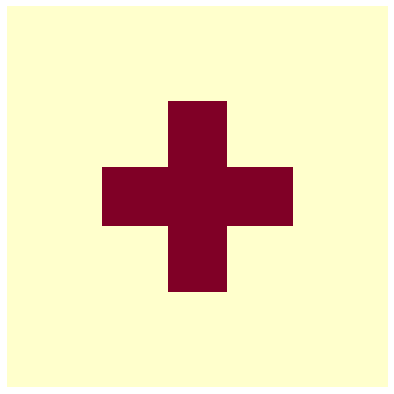

In [384]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'device is set to : {device}')

def generate_samples(n_samples, size):
    mean = 0
    variance = 3
    std_dev = torch.sqrt(torch.tensor(variance))
    tensor = np.random.normal(mean, std_dev, (n_samples, size))
    tensor = torch.from_numpy(tensor).float()

    
    x, y = np.meshgrid(np.linspace(-3, 3, size), np.linspace(-3, 3, size))

    Weight = np.zeros_like(x)
    Weight[(x >= -0.5) & (x <= 0.5) & (y >= -1.5) & (y <= 1.5)] = 1
    Weight[(y >= -0.5) & (y <= 0.5) & (x >= -1.5) & (x <= 1.5)] = 1
    Weight = torch.from_numpy(Weight).float()

    output  = torch.matmul(tensor, Weight)

    mean = 0
    variance = 1
    std_dev = torch.sqrt(torch.tensor(variance))
    noise = np.random.normal(mean, std_dev, (n_samples, size))
    noise = torch.from_numpy(noise).float()

    return tensor.to(device), output.to(device), Weight.to(device), (tensor+noise).to(device)

n_samples = 5000
size = 64

samples, y, W, x = generate_samples(n_samples, size)


fig = plt.figure(figsize=(10,7))
plt.imshow(W.cpu(), cmap='YlOrRd')
plt.axis('off')
plt.show()

# Basic Linear Model

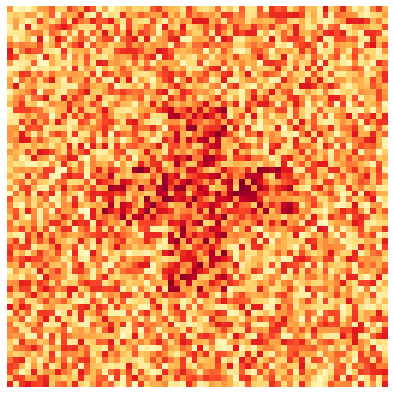

In [393]:
class simple_linear(nn.Module):
    def __init__(self):
        super(simple_linear, self).__init__()
        self.fc = nn.Linear(in_features= size, out_features=size, bias=False)
    def forward(self, x):
        # x = x.reshape(-1,size)
        return self.fc(x)
    
model = simple_linear().to(device)

# Train for 750 epochs
criterion = nn.MSELoss(reduction='mean')
optimizer = optim.SGD(model.parameters(), lr=1e-3)

n_epochs = 750
l1_lambda = 1e-3


for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(x)
    loss = criterion(outputs, y)
    l1_reg = 0
    for param in model.parameters():
        l1_reg += torch.abs(param).sum()
    loss += l1_lambda * l1_reg

    loss.backward()
    optimizer.step()

W_fc = model.fc.weight

fig = plt.figure(figsize=(10,7))
plt.imshow(W_fc.detach().cpu(), cmap='YlOrRd')
plt.axis('off')
plt.show()


# Basic TRL Model

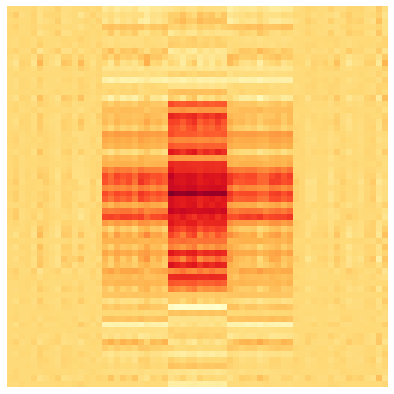

In [394]:
class simple_trl(nn.Module):
    def __init__(self):
        super(simple_trl, self).__init__()
        self.trl = tltorch.TRL(input_shape=(64), rank=(5,64), output_shape=(64), bias=False, factorization='tucker')
    def forward(self, x):
        return self.trl(x)
    
model = simple_trl().to(device)

# Train for 750 epochs
criterion = nn.MSELoss(reduction='mean')
optimizer = optim.SGD(model.parameters(), lr=1e-3)

n_epochs = 750
l1_lambda = 1e-3


for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(x)
    loss = criterion(outputs, y)
    l1_reg = 0
    for param in model.parameters():
        l1_reg += torch.abs(param).sum()
    loss += l1_lambda * l1_reg

    loss.backward()
    optimizer.step()
    
W_trl = model.trl.weight.to_tensor()

fig = plt.figure(figsize=(10,7))
plt.imshow(W_trl.detach().cpu(), cmap='YlOrRd')
plt.axis('off')
plt.show()


# Basic Attached Model

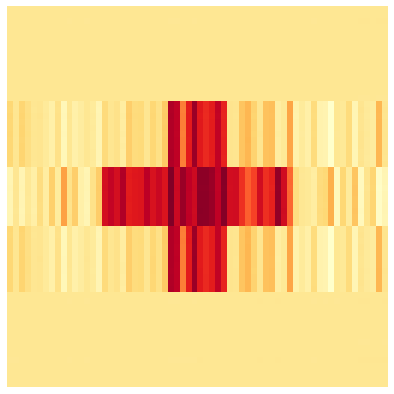

In [408]:
class simple_attached(nn.Module):
    def __init__(self):
        super(simple_attached, self).__init__()
        self.reshape = reshape(split=[1,1,2], map_type=1, device=device)
        self.trl = tltorch.TRL(input_shape=(1,1,2,1,1,32), rank=(1,1,2,1,1,5,64), output_shape=(64), bias=False, factorization='tucker')
    def forward(self, x):
        x = x.unsqueeze(dim=1).unsqueeze(dim=2)
        return self.trl(self.reshape(x))
    
model = simple_attached().to(device)

# Train for 750 epochs
criterion = nn.MSELoss(reduction='mean')
# optimizer = optim.SGD(model.parameters(), lr=1e-4)
optimizer = optim.Adam(model.parameters())

n_epochs = 750
l1_lambda = 1e-3


for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(x)
    loss = criterion(outputs, y)
    l1_reg = 0
    for param in model.parameters():
        l1_reg += torch.abs(param).sum()
    # loss += l1_lambda * l1_reg
    
    loss.backward()
    optimizer.step()

W_attached = rearrange(model.trl.weight.to_tensor(), 'a b c d e f g -> g (c f) (b e) (a d)').squeeze()

fig = plt.figure(figsize=(10,7))
plt.imshow(W_attached.detach().cpu(), cmap='YlOrRd')
plt.axis('off')
plt.show()


# Basic Compressed Model

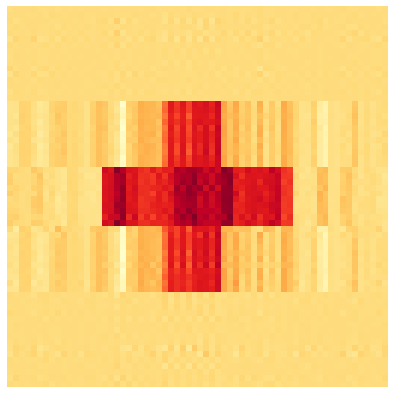

In [409]:
class simple_attached(nn.Module):
    def __init__(self):
        super(simple_attached, self).__init__()
        self.reshape = reshape(split=[1,1,2], map_type=2, device=device)
        self.trl = tltorch.TRL(input_shape=(1,1,2,1,1,32), rank=(1,1,2,1,1,5,64), output_shape=(64), bias=False, factorization='tucker')
    def forward(self, x):
        x = x.unsqueeze(dim=1).unsqueeze(dim=2)
        return self.trl(self.reshape(x))
    
model = simple_attached().to(device)

# Train for 5 epochs
criterion = nn.MSELoss(reduction='mean')
# optimizer = optim.SGD(model.parameters(), lr=1e-3)
optimizer = optim.Adam(model.parameters())

n_epochs = 750
l1_lambda = 1e-3


for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(x)
    loss = criterion(outputs, y)
    l1_reg = 0
    for param in model.parameters():
        l1_reg += torch.abs(param).sum()
    # loss += l1_lambda * l1_reg

    loss.backward()
    optimizer.step()

W_compressed = rearrange(model.trl.weight.to_tensor(), 'a b c d e f g -> g (f c) (e b) (d a)').squeeze()

fig = plt.figure(figsize=(10,7))
plt.imshow(W_compressed.detach().cpu(), cmap='YlOrRd')
plt.axis('off')
plt.show()


# All In One

## Generate all samples for the study

In [382]:
samples, y, W, x = generate_samples(n_samples, size)

samples = {}
y ={}
W = {}
x = {}
size = 64 # models are made for this size
for i in range(20):
    data, targets, W[i], x[i] = generate_samples((i+1)*1000, size)
    X_train, X_test, y_train, y_test = train_test_split(data, targets, test_size=0.2)
    samples[i] = {'train':X_train, 'test':X_test}
    y[i] = {'train':y_train, 'test':y_test}

print('Generation Done!')

Generation Done!


# Train and Test on models 